# Ex8 CNN fashion MNIST

In [1]:
import torch
import torch.nn as nn
import torchvision 
import torchvision.datasets
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as opt
import datetime


In [2]:
train_dataset = torchvision.datasets.FashionMNIST('../DATA',train=True,transform=torchvision.transforms.ToTensor(),download=True)
test_dataset = torchvision.datasets.FashionMNIST('../DATA',train=False,transform=torchvision.transforms.ToTensor(),download=True)

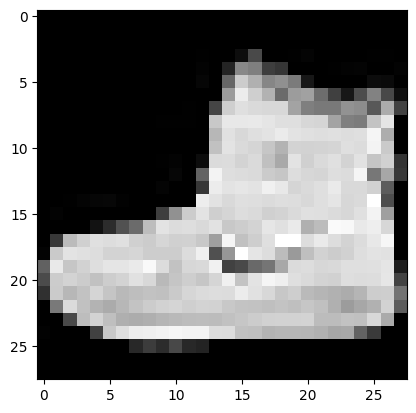

In [3]:
plt.imshow(train_dataset.data[0],cmap='grey')

In [4]:
train_dataloader = torch.utils.data.DataLoader(train_dataset,batch_size=128,shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset,batch_size=128,shuffle=False)

## let's implement leNet-5 https://en.wikipedia.org/wiki/LeNet

In [5]:
class LeNet5(nn.Module):
    def __init__(self, in_features, classes):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_features,out_channels=6,kernel_size=5,padding=2) 
        self.act1 = nn.ReLU()
        self.pool1= nn.AvgPool2d(2,2) #14x14 (mnist) 

        self.conv2 = nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5) #14 - 5 +1 = 10 (MNIST )
        self.act2 = nn.ReLU()
        self.pool2= nn.AvgPool2d(2,2) # 5x5 

        self.flat = nn.Flatten()

        #input dim is kernel shape * out channel  =5*5*16
        self.dense1 = nn.Linear(5*5*16,120)
        self.act3 = nn.ReLU()
        self.dense2 = nn.Linear(120,84)
        self.act4 = nn.ReLU()
        self.dense3 = nn.Linear(84,classes)

    def forward(self,x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.flat(x)
        x = self.dense1(x)
        x = self.act3(x)
        x = self.dense2(x)
        x = self.act4(x)
        x = self.dense3(x) #logits
        return x 
    



In [6]:
device = torch.device('cuda:0' if  torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [7]:
model = LeNet5(1,10)
criterion = nn.CrossEntropyLoss()
model.to(device=device)
optimizer = opt.SGD(model.parameters(),lr=0.01)

## training loop

In [8]:
epochs = 100

train_losses = []
test_loseses = [] 
train_accuracy =[]
test_accuracy =[]

In [ ]:
starttime = datetime.datetime.now()

for epoch in range(1,epochs+1):
    tmp_loss =[]
    total_training_n = 0
    correct__training_n = 0

    for inputs,targets in train_dataloader:
        optimizer.zero_grad()

        inputs = inputs.to(device)
        targets = targets.to(device)
        y_hat = model(inputs)
        loss = criterion(y_hat,targets)
        loss.backward()
        optimizer.step()

        tmp_loss.append(loss.item())
        with torch.no_grad():
            total_training_n += inputs.shape[0]
            _,argmx = torch.max(y_hat,1)
            correct__training_n += np.sum(targets.cpu().numpy() == argmx.cpu().numpy())
    train_losses.append(np.mean(tmp_loss))
    train_accuracy.append(correct__training_n/total_training_n)

    # test 
    tmp_loss =[]
    total_test_n = 0
    correct__test_n = 0
    for inputs,targets in test_dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        y_hat = model(inputs)
        loss = criterion(y_hat,targets)
        tmp_loss.append(loss.item())
        with torch.no_grad():
            total_test_n += inputs.shape[0]
            _,argmx = torch.max(y_hat,1)
            correct__test_n += np.sum(targets.cpu().numpy() == argmx.cpu().numpy())

    test_loseses.append(np.mean(tmp_loss))
    test_accuracy.append(correct__test_n/total_test_n)
    print(f'{datetime.datetime.now()-starttime} {epoch}/{epochs} training loss(avg) {train_losses[-1]} train_acc: {train_accuracy[-1]} test loss {test_loseses[-1]} test_acc: {test_accuracy[-1]}')


0:00:03.437990 1/100 training loss(avg) 2.3019009704020488 train_acc: 0.13368333333333332 test loss 2.2973475637315195 test_acc: 0.1863
0:00:06.631946 2/100 training loss(avg) 2.2735635532753298 train_acc: 0.21921666666666667 test loss 2.1762676601168476 test_acc: 0.3584
0:00:09.846457 3/100 training loss(avg) 1.2644760923853307 train_acc: 0.5603333333333333 test loss 0.9140747679939752 test_acc: 0.6544
0:00:13.367999 4/100 training loss(avg) 0.8159014853333105 train_acc: 0.6915333333333333 test loss 0.7773813793930826 test_acc: 0.6984
0:00:17.441196 5/100 training loss(avg) 0.7319199506407862 train_acc: 0.722 test loss 0.7826928654803506 test_acc: 0.6971
0:00:21.792895 6/100 training loss(avg) 0.6836142630846516 train_acc: 0.7386666666666667 test loss 0.6644401014605655 test_acc: 0.7476
0:00:26.290935 7/100 training loss(avg) 0.6433095524687249 train_acc: 0.7547166666666667 test loss 0.6653544121905218 test_acc: 0.7491
0:00:30.751532 8/100 training loss(avg) 0.6154527352181579 train_a

# plotting

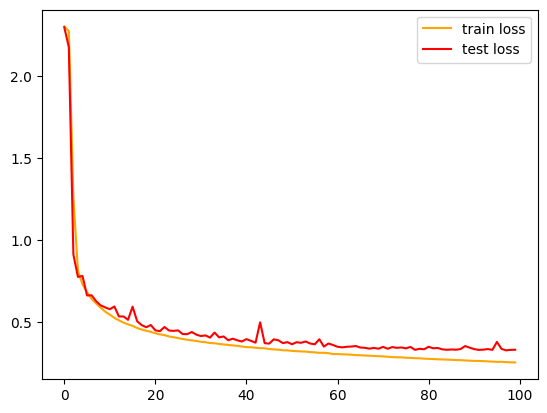

In [10]:
its = [x for x in range(epochs)]
plt.plot(train_losses,label='train loss',color='orange')
plt.plot(test_loseses,label='test loss',color='red')
plt.legend()

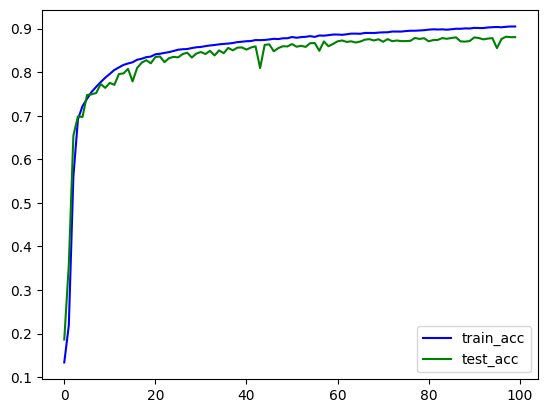

In [11]:
plt.plot(train_accuracy,label='train_acc',color='blue')
plt.plot(test_accuracy,label='test_acc',color='green')
plt.legend()

In [12]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [13]:
y_test = test_dataset.targets
y_test = y_test.detach().cpu().numpy()
y_test.shape

(10000,)

In [14]:
y= []
y_hat = []
for inputs,outputs in test_dataloader:
    inputs,outputs = inputs.to(device),outputs.to(device)
    predict = model(inputs)
    _,predict = torch.max(predict,1)
    y = np.concatenate((y,outputs.cpu().numpy()))
    y_hat = np.concatenate((y_hat,predict.cpu().numpy()))


In [15]:
cm = confusion_matrix(y,y_hat)
cm

array([[809,   1,  11,  37,   3,   1, 128,   0,  10,   0],
       [  3, 959,   3,  25,   4,   0,   5,   0,   1,   0],
       [ 11,   0, 777,  18, 107,   1,  86,   0,   0,   0],
       [ 16,  10,   7, 923,  21,   0,  19,   0,   4,   0],
       [  1,   1,  71,  48, 818,   0,  59,   0,   2,   0],
       [  0,   0,   0,   2,   0, 952,   0,  34,   2,  10],
       [111,   1,  78,  40,  89,   0, 672,   0,   9,   0],
       [  0,   0,   0,   0,   0,   9,   0, 976,   0,  15],
       [  3,   0,   4,   5,   2,   1,   5,   5, 975,   0],
       [  1,   0,   0,   0,   0,   6,   0,  51,   0, 942]], dtype=int64)

In [16]:
len(test_dataset.classes)

10

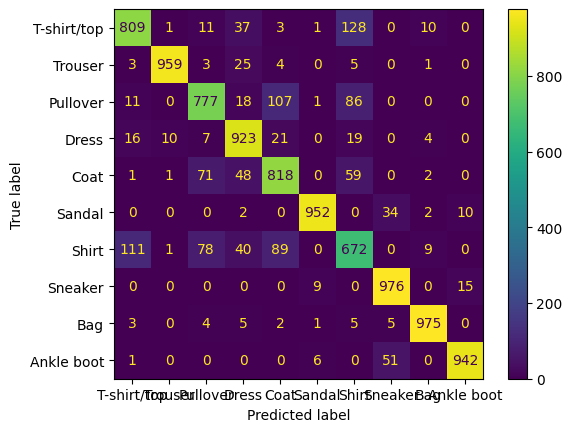

In [17]:
ConfusionMatrixDisplay.from_predictions(y,y_hat,display_labels=test_dataset.classes)

Text(0.5, 1.0, 'y_true Coat y_hat Shirt')

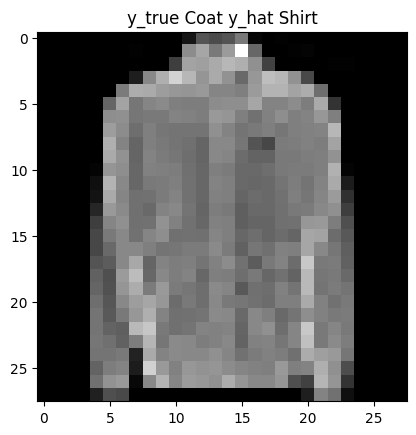

In [25]:
missclassified_idxs =np.where(y!=y_hat)[0]
i = np.random.choice(missclassified_idxs)
plt.imshow(test_dataset.data[i],cmap='gray')
plt.title(f'y_true {test_dataset.classes[int(y[i])]} y_hat {test_dataset.classes[int(y_hat[i])]}')